In [1]:
from densities import *
from potentials import *
from utils import *
from constants import *

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

import agama
agama.setUnits(mass=1, length=1, velocity= KPCGYR_TO_KMS)

In [2]:
def density_func(x, y, z, params):

    return MiyamotoNagai_density(x, y, z, params) + DehnenAlyBar_density(x, y, z, params)

params = {
    "logM_disc": 10.0,
    "Rs_disc": 3.0,
    "Hs_disc": 0.3,
    "logM_bar": 10.0,
    'Rs_bar': 4.0 / 2,
    'Hs_bar': 0.3,
    'L_bar': 4.0,
    'gamma_bar': 0.7,
    'model_bar_idx': 3,
    'phi_bar': 0.,
    'x_origin': 0.,
    'y_origin': 0.,
    'z_origin': 0.,
    'dirx': 0.,
    'diry': 0.,
    'dirz': 1.,
}

def density_func_agama(x):
    val = density_func(x[:, 0], x[:, 1], x[:, 2],  params)
    return np.where((val>0) & (np.isfinite(val)), val, 0)

disc_density_agama = agama.Density(density = density_func_agama)
# disc_density_agama = agama.Potential(type = 'Cylspline', density = density_func_agama, symmetry = 'Triaxial', Rmin = 0.1, Rmax = 30, zmin = 0.01, zmax=15)

pos, mass = disc_density_agama.sample(int(1e6))

/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_59008/4218876504.py:28: RuntimeWarning: symmetry is not provided, some methods will not be available
  disc_density_agama = agama.Density(density = density_func_agama)
/Users/hanyuan/anaconda3/envs/astro312/lib/python3.12/site-packages/jax/_src/abstract_arrays.py:135: RuntimeWarning: overflow encountered in cast
  return literals.TypedNdArray(np.asarray(x, dtype), weak_type=False)
/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_59008/4218876504.py:3: RuntimeWarning: overflow encountered in cast
  return MiyamotoNagai_density(x, y, z, params) + DehnenAlyBar_density(x, y, z, params)


/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_59008/2551239665.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.contour(xmid, ymid, np.log10(H).T, levels=10, colors='white')


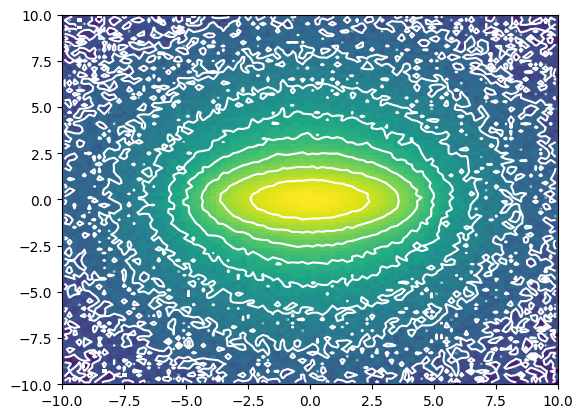

In [3]:
H, xedge, yedge, _ = plt.hist2d(pos[:, 0], pos[:, 1], bins=100, range=[[-10, 10], [-10, 10]], norm = 'log')
xmid, ymid = 0.5 * (xedge[1:] + xedge[:-1]), 0.5 * (yedge[1:] + yedge[:-1])

plt.contour(xmid, ymid, np.log10(H).T, levels=10, colors='white')

Time taken to compute acceleration (us): 0.00 seconds
Time taken to compute acceleration (agama): 0.00 seconds
R fractional diff: mean=2.2590e-04, median=2.0986e-04, p95=4.8859e-04
phi fractional diff: mean=4.3023e-03, median=9.3356e-04, p95=2.1324e-02
z fractional diff: mean=5.0041e-04, median=2.7616e-04, p95=1.9614e-03


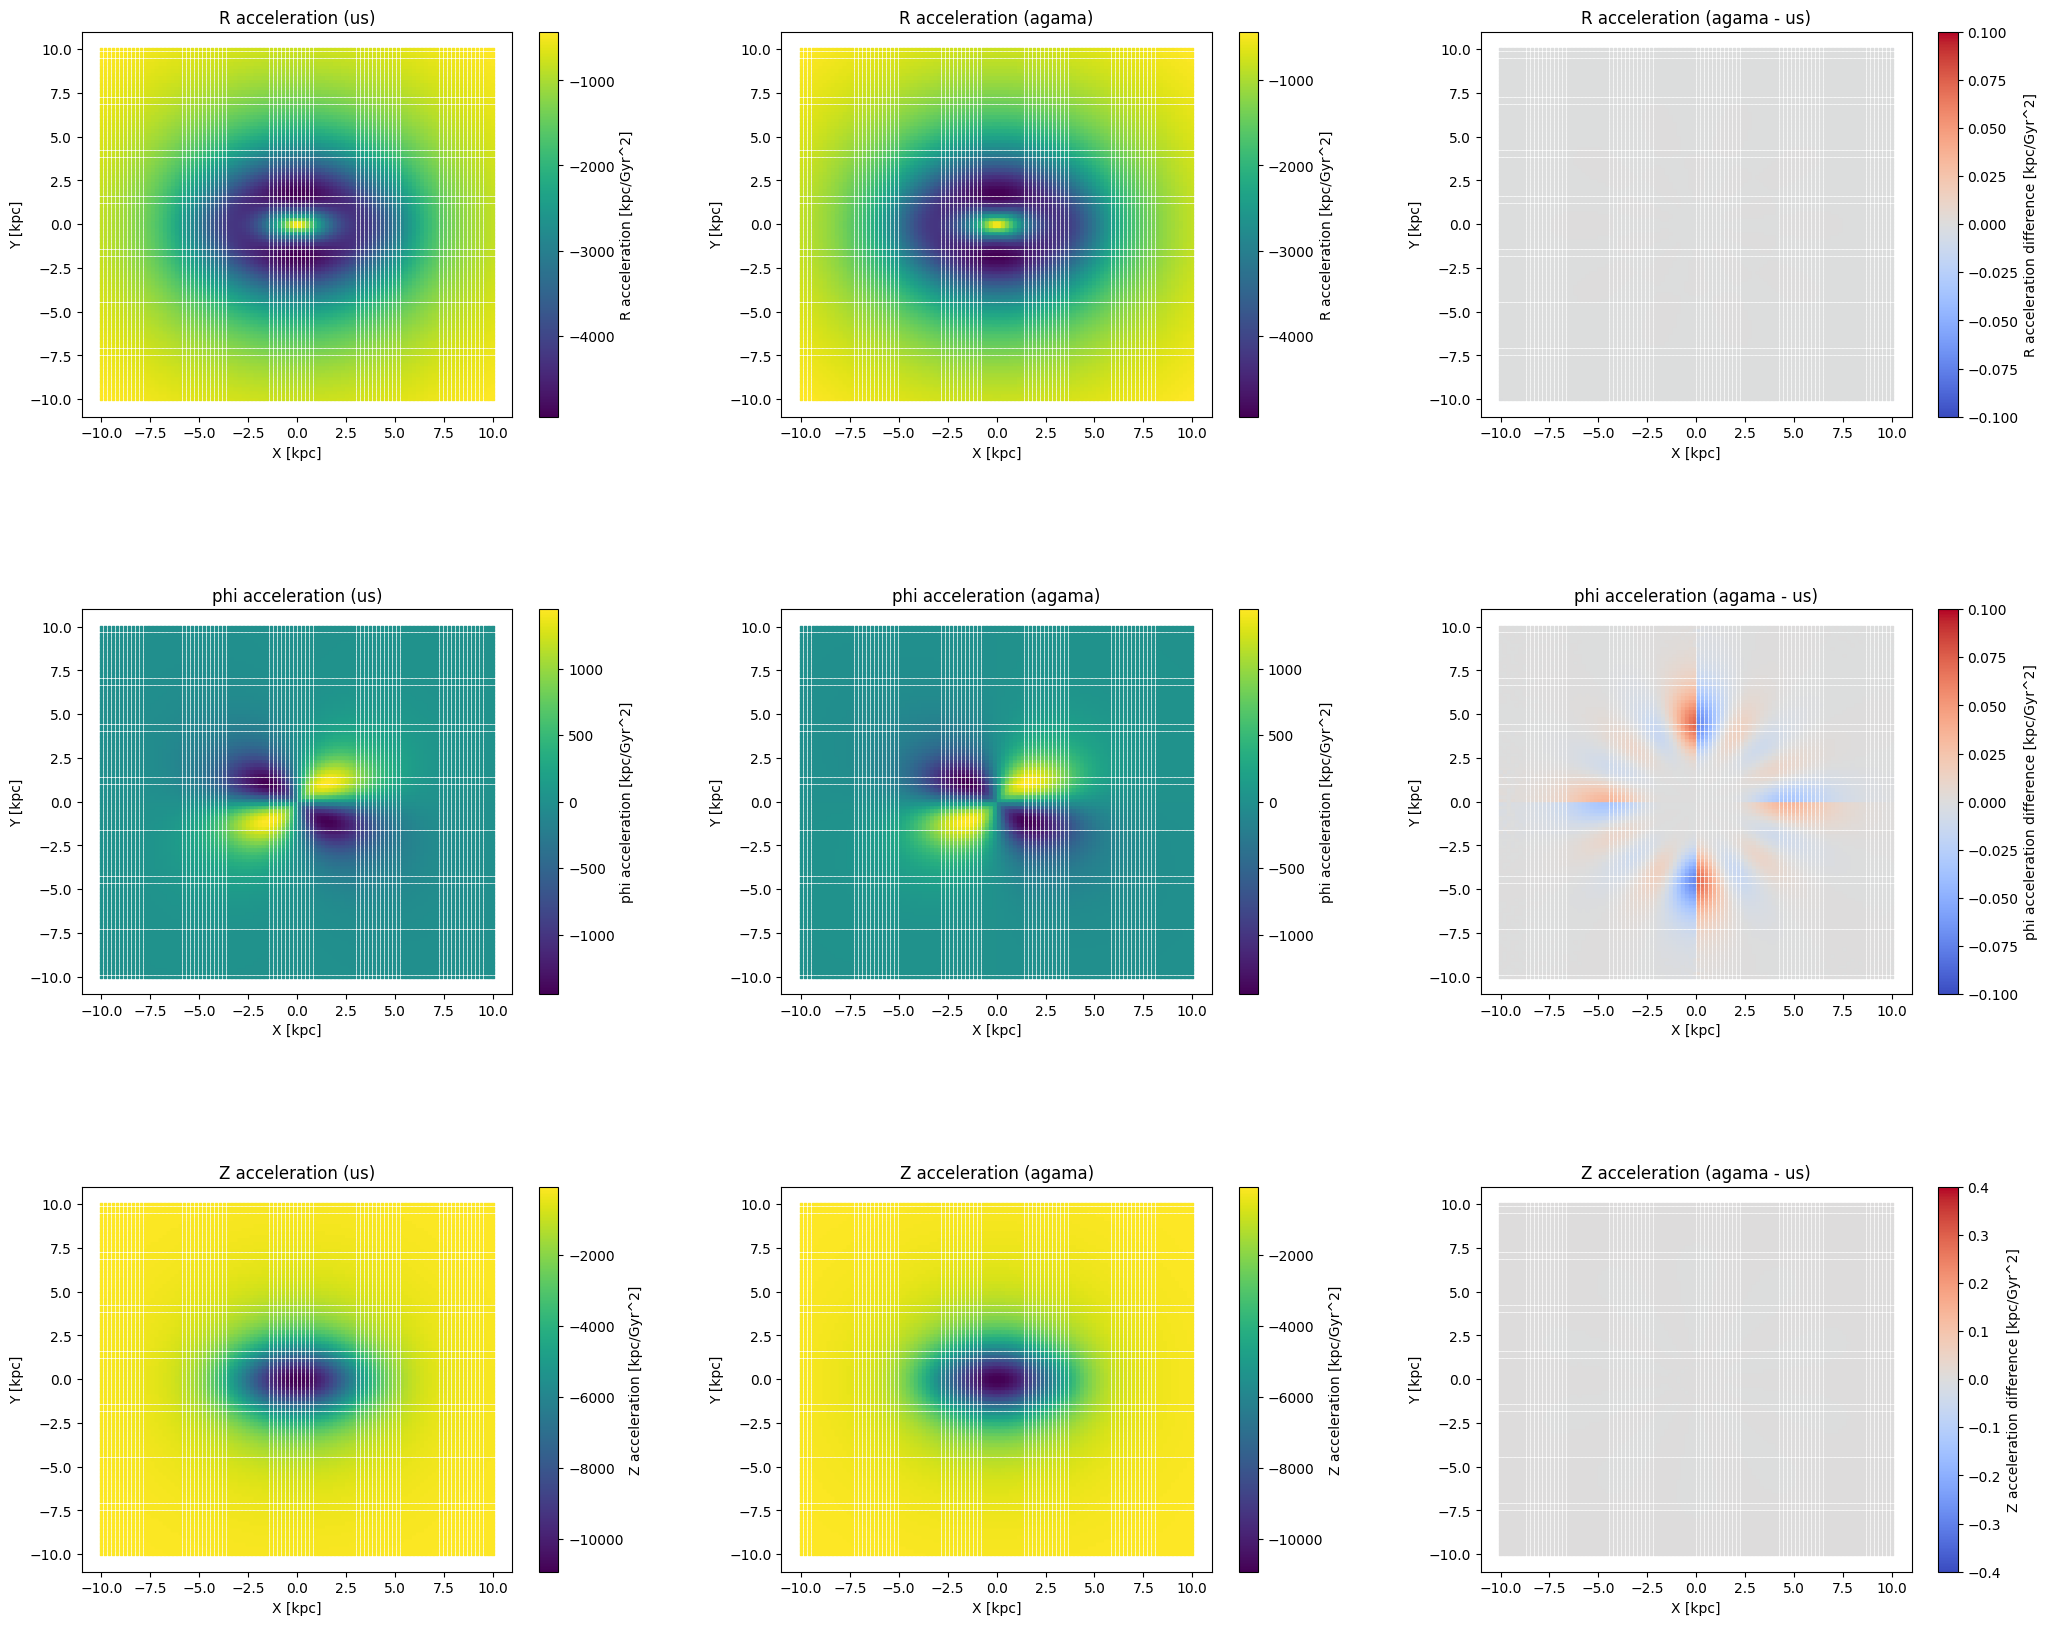

In [4]:
import time

params = {
    "logM_disc": 10.0,
    "Rs_disc": 3.0,
    "Hs_disc": 0.3,
    "logM_bar": 10.0,
    'Rs_bar': 4.0 / 2,
    'Hs_bar': 0.3,
    'L_bar': 4.0,
    'gamma_bar': 0.7,
    'model_bar_idx': 3,
    'phi_bar': 0.,
    'x_origin': 0.,
    'y_origin': 0.,
    'z_origin': 0.,
    'dirx': 0.,
    'diry': 0.,
    'dirz': 1.,
}

def getCylindricalFromCartesian_clockwise(x, y, vx, vy):
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    vR = (x*vx + y*vy) / R
    vphi = -(x*vy - y*vx) / R
    return R, phi, vR, vphi

# def acc_func(x, y, z, params):
#     return MiyamotoNagai_acceleration(x, y, z, params) + DehnenAlyBar_acceleration(x, y, z, params)

# bar_fns = make_DehnenAlyBar_fns(mtype='T3', barred=True, crossed=False)

# Combined MN + bar acceleration via single jax.grad
@jax.jit
def acc_func(x, y, z, params):
    def pot(pos):
        return (MiyamotoNagai_potential(pos[0], pos[1], pos[2], params)
                + DehnenAlyBar_potential(pos[0], pos[1], pos[2], params))
    return -jax.grad(pot)(jnp.array([x, y, z]))

NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-3, 30.0, 1e-3, 15.0, 8.

x_c, y_c = np.linspace(-10, 10, 100), np.linspace(-10, 10, 100)
X_c, Y_c = np.meshgrid(x_c, y_c)
X_c, Y_c = X_c.flatten(), Y_c.flatten()
Z_c = np.ones_like(X_c) * 1#1e-4

pts = np.array([X_c, Y_c, Z_c]).T
get_acc_vec = jax.jit(jax.vmap(acc_func, in_axes=(0,0,0,None)))
# warm-up JIT compile before timing
_ = get_acc_vec(pts[:,0]*0.99, pts[:,1]*0.99, pts[:,2]*0.99, params)
_.block_until_ready()
time_start = time.time()
acc_pts_us = get_acc_vec(pts[:,0], pts[:,1], pts[:,2], params)
acc_pts_us.block_until_ready()
time_end = time.time()
print(f"Time taken to compute acceleration (us): {time_end - time_start:.2f} seconds") 
R, phi, F_R, F_phi = getCylindricalFromCartesian_clockwise(pts[:,0], pts[:,1], acc_pts_us[:,0], acc_pts_us[:,1])
acc_pts_us = acc_pts_us.at[:,0].set(F_R)
acc_pts_us = acc_pts_us.at[:,1].set(F_phi)

disc_density_agama = agama.Potential(
    type='CylSpline',
    density=density_func_agama,
    symmetry='Triaxial',
    mmax=int(Mmax),
    gridSizeR=int(NR),
    gridSizeZ=int(NZ + 1),  # includes z=0 node
    Rmin=float(Rmin),
    Rmax=float(Rmax),
    zmin=float(Zmin),
    zmax=float(Zmax),
    fixOrder=True,
)
time_start = time.time()
acc_pts_agama = disc_density_agama.force(pts)
time_end = time.time()
print(f"Time taken to compute acceleration (agama): {time_end - time_start:.2f} seconds")
R, phi, F_R, F_phi = getCylindricalFromCartesian_clockwise(pts[:,0], pts[:,1], acc_pts_agama[:,0], acc_pts_agama[:,1])
acc_pts_agama[:,0] = F_R
acc_pts_agama[:,1] = F_phi

eps_rel = 1e-8
denom = np.fabs(acc_pts_agama)
rel = np.fabs(acc_pts_agama - acc_pts_us) / np.maximum(denom, eps_rel)

comp_names = ['R', 'phi', 'z']
for i, name in enumerate(comp_names):
    # Exclude points where the AGAMA reference value is extremely close to 0.
    mask = denom[:, i] > 1e-6
    comp_rel = rel[mask, i]
    print(f'{name} fractional diff: mean={comp_rel.mean():.4e}, median={np.median(comp_rel):.4e}, p95={np.percentile(comp_rel,95):.4e}')

_plot = True
if _plot:
    fig, ax = plt.subplots(3,3, figsize=(25,20), gridspec_kw={'hspace':0.5, 'wspace':0.3})
    cb = ax[0,0].scatter(X_c, Y_c, c=acc_pts_us[:,0], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[0,0], label='R acceleration [kpc/Gyr^2]')
    ax[0,0].set_title('R acceleration (us)')
    ax[0,0].set_xlabel('X [kpc]')
    ax[0,0].set_ylabel('Y [kpc]')
    cb = ax[0,1].scatter(X_c, Y_c, c=acc_pts_agama[:,0], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[0,1], label='R acceleration [kpc/Gyr^2]')
    ax[0,1].set_title('R acceleration (agama)')
    ax[0,1].set_xlabel('X [kpc]')
    ax[0,1].set_ylabel('Y [kpc]')
    res = (acc_pts_agama[:,0] - acc_pts_us[:,0]) / np.fabs(acc_pts_agama[:,0])
    cb = ax[0,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.1, vmax = 0.1)
    plt.colorbar(cb, ax=ax[0,2], label='R acceleration difference [kpc/Gyr^2]')
    ax[0,2].set_title('R acceleration (agama - us)')
    ax[0,2].set_xlabel('X [kpc]')
    ax[0,2].set_ylabel('Y [kpc]')

    cb = ax[1,0].scatter(X_c, Y_c, c=acc_pts_us[:,1], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[1,0], label='phi acceleration [kpc/Gyr^2]')
    ax[1,0].set_title('phi acceleration (us)')
    ax[1,0].set_xlabel('X [kpc]')
    ax[1,0].set_ylabel('Y [kpc]')
    cb = ax[1,1].scatter(X_c, Y_c, c=acc_pts_agama[:,1], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[1,1], label='phi acceleration [kpc/Gyr^2]')
    ax[1,1].set_title('phi acceleration (agama)')
    ax[1,1].set_xlabel('X [kpc]')
    ax[1,1].set_ylabel('Y [kpc]')
    res = (acc_pts_agama[:,1] - acc_pts_us[:,1]) / np.fabs(acc_pts_agama[:,1])
    cb = ax[1,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.1, vmax = 0.1)
    plt.colorbar(cb, ax=ax[1,2], label='phi acceleration difference [kpc/Gyr^2]')
    ax[1,2].set_title('phi acceleration (agama - us)')
    ax[1,2].set_xlabel('X [kpc]')
    ax[1,2].set_ylabel('Y [kpc]')

    cb = ax[2,0].scatter(X_c, Y_c, c=acc_pts_us[:,2], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[2,0], label='Z acceleration [kpc/Gyr^2]')
    ax[2,0].set_title('Z acceleration (us)')
    ax[2,0].set_xlabel('X [kpc]')
    ax[2,0].set_ylabel('Y [kpc]')

    cb = ax[2,1].scatter(X_c, Y_c, c=acc_pts_agama[:,2], s=3, marker = 's', cmap='viridis')
    plt.colorbar(cb, ax=ax[2,1], label='Z acceleration [kpc/Gyr^2]')
    ax[2,1].set_title('Z acceleration (agama)')
    ax[2,1].set_xlabel('X [kpc]')
    ax[2,1].set_ylabel('Y [kpc]')

    res = (acc_pts_agama[:,2] - acc_pts_us[:,2]) / np.fabs(acc_pts_agama[:,2])
    cb = ax[2,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.4, vmax = 0.4)
    plt.colorbar(cb, ax=ax[2,2], label='Z acceleration difference [kpc/Gyr^2]')
    ax[2,2].set_title('Z acceleration (agama - us)')
    ax[2,2].set_xlabel('X [kpc]')
    ax[2,2].set_ylabel('Y [kpc]')

    plt.show()